# [MODEL]

기존 6종 EfficientNetB0 분류 모델(`ingredient_model.keras`)을 20종(기존 6종 + 신규 14종)으로 확장하는 v2 학습 노트북이다.
기존 모델의 백본 가중치를 초기값으로 활용하는 warm start 전이학습을 시도하고,
ImageDataGenerator 기반 증강, 5~10 epoch 학습, 학습 곡선 시각화,
test set 전체/클래스별 정확도 및 혼동행렬(대파-양파 등 유사 클래스 쌍 주의),
**기존 6종 정확도의 재학습 전/후 비교**, 모델·클래스명(v2) 저장, 20종 예측 데모까지 다룬다.

## 0. 환경 준비 및 Google Drive 마운트

이 노트북은 VS Code가 아닌 **Google Colab**에서 실행한다.
이미지 데이터셋과 기존 모델 산출물(`ingredient_model.keras`)이 모두 Google Drive에 있으므로,
Drive를 마운트해 해당 경로를 그대로 읽고 쓴다.

In [1]:
# [MODEL] Colab 환경에서 Google Drive를 마운트하여 데이터셋과 기존 모델 산출물 경로를 확보한다
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# [MODEL] 재현성과 데이터 처리, 시각화, 평가에 필요한 라이브러리를 임포트한다
import os
import json
import random
import shutil
import math

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. 클래스 목록 확정 (기존 6종 + 신규 14종 = 20종)

`docs/model_v2_plan.md`에서 정리한 최종 20종 클래스 목록을 그대로 사용한다.
기존 6종은 `ingredient_model.keras` 학습 당시와 동일한 순서를 유지해야
이후 warm start 시 백본 가중치 재사용이 의미를 가진다.

In [3]:
# [MODEL] Google Drive 내 데이터/산출물 경로 (실제 Drive 폴더 구조에 맞게 수정)
# RAW_DATA_DIR: 클래스별 폴더(RAW_DATA_DIR/클래스명/*.jpg)로 구성된 20종 원본 이미지가 위치한 Drive 경로
RAW_DATA_DIR = '/content/drive/MyDrive/ingredient-project/data/raw_v2'
# SPLIT_DATA_DIR: train/val/test로 분리된 이미지를 저장할 Drive 경로
SPLIT_DATA_DIR = '/content/drive/MyDrive/ingredient-project/data/split_v2'
# ARTIFACT_DIR: 기존 ingredient_model.keras가 저장돼 있고, v2 산출물도 저장할 Drive 경로
ARTIFACT_DIR = '/content/drive/MyDrive/ingredient-project/model/artifacts'

os.makedirs(SPLIT_DATA_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 기존 6종: ingredient_model.keras 학습 당시와 동일한 순서를 유지한다
OLD_CLASS_NAMES = ['potato', 'carrot', 'cabbage', 'tomato', 'eggplant', 'paprika']

# 신규 14종 (docs/model_v2_plan.md 기준)
NEW_CLASS_NAMES = [
    'pork', 'chicken', 'onion', 'egg', 'garlic', 'tofu', 'cheese',
    'somyeon', 'enoki_mushroom', 'green_onion', 'vienna_sausage',
    'canned_tuna', 'cucumber', 'kimchi',
]

# 기존 6종을 앞에 두어 class_names_v2.json 인덱스가 기존 모델과 최대한 호환되도록 한다
CLASS_NAMES = OLD_CLASS_NAMES + NEW_CLASS_NAMES
assert len(CLASS_NAMES) == 20, 'v2 클래스는 총 20종이어야 한다'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print('v2 전체 클래스 수:', len(CLASS_NAMES))
print(CLASS_NAMES)

v2 전체 클래스 수: 20
['potato', 'carrot', 'cabbage', 'tomato', 'eggplant', 'paprika', 'pork', 'chicken', 'onion', 'egg', 'garlic', 'tofu', 'cheese', 'somyeon', 'enoki_mushroom', 'green_onion', 'vienna_sausage', 'canned_tuna', 'cucumber', 'kimchi']


## 2. train / validation / test 8:1:1 분할

클래스별 폴더 구조(`RAW_DATA_DIR/클래스명/*.jpg`)를 가정하고,
20개 클래스 각각의 이미지를 8:1:1 비율로 분리하여 `SPLIT_DATA_DIR` 하위에 복사한다.

In [4]:
# [MODEL] 클래스별 이미지를 train/val/test 폴더로 8:1:1 비율로 복사한다
def split_dataset(raw_dir, split_dir, class_names, ratios=(0.8, 0.1, 0.1), seed=SEED):
    rng = random.Random(seed)
    for split in ['train', 'val', 'test']:
        for cls in class_names:
            os.makedirs(os.path.join(split_dir, split, cls), exist_ok=True)

    for cls in class_names:
        cls_dir = os.path.join(raw_dir, cls)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        rng.shuffle(files)

        n_total = len(files)
        n_train = int(n_total * ratios[0])
        n_val = int(n_total * ratios[1])

        splits = {
            'train': files[:n_train],
            'val': files[n_train:n_train + n_val],
            'test': files[n_train + n_val:],
        }

        for split, split_files in splits.items():
            for fname in split_files:
                src = os.path.join(cls_dir, fname)
                dst = os.path.join(split_dir, split, cls, fname)
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)

        print(f'{cls}: train={len(splits["train"])}, val={len(splits["val"])}, test={len(splits["test"])}')


# 20종 전체 데이터를 8:1:1로 분리한다 (이미 분리되어 있다면 재실행 불필요)
split_dataset(RAW_DATA_DIR, SPLIT_DATA_DIR, CLASS_NAMES)

train_dir = os.path.join(SPLIT_DATA_DIR, 'train')
val_dir = os.path.join(SPLIT_DATA_DIR, 'val')
test_dir = os.path.join(SPLIT_DATA_DIR, 'test')

potato: train=400, val=50, test=50
carrot: train=400, val=50, test=50
cabbage: train=400, val=50, test=50
tomato: train=550, val=68, test=70
eggplant: train=400, val=50, test=50
paprika: train=480, val=60, test=60
pork: train=488, val=61, test=62
chicken: train=508, val=63, test=64
onion: train=480, val=60, test=60
egg: train=430, val=53, test=55
garlic: train=579, val=72, test=73
tofu: train=193, val=24, test=25
cheese: train=502, val=62, test=64
somyeon: train=257, val=32, test=33
enoki_mushroom: train=480, val=60, test=60
green_onion: train=496, val=62, test=62
vienna_sausage: train=496, val=62, test=62
canned_tuna: train=489, val=61, test=62
cucumber: train=495, val=61, test=63
kimchi: train=496, val=62, test=62


In [5]:
# [MODEL] Drive I/O 병목을 피하기 위해 split 데이터를 Colab 로컬 디스크로 복사한다
LOCAL_SPLIT_DIR = '/content/split_v2_local'

if not os.path.exists(LOCAL_SPLIT_DIR):
    shutil.copytree(SPLIT_DATA_DIR, LOCAL_SPLIT_DIR)
    print('로컬 복사 완료:', LOCAL_SPLIT_DIR)
else:
    print('이미 로컬에 존재함:', LOCAL_SPLIT_DIR)

# 이후 셀에서는 로컬 경로를 사용하도록 재할당한다
train_dir = os.path.join(LOCAL_SPLIT_DIR, 'train')
val_dir = os.path.join(LOCAL_SPLIT_DIR, 'val')
test_dir = os.path.join(LOCAL_SPLIT_DIR, 'test')

로컬 복사 완료: /content/split_v2_local


## 3. ImageDataGenerator 증강 설정 (회전 · 좌우 반전 · 밝기 조절)

이번 v2 파이프라인은 `ImageDataGenerator.flow_from_directory`를 학습/평가에 직접 사용한다.
train에는 회전·좌우 반전·밝기 조절 증강을 적용하고, val/test는 스케일링만 수행한다.

In [6]:
# [MODEL] train에만 적용할 증강: 회전, 좌우 반전, 밝기 조절
train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
)

# validation/test에는 증강 없이 원본 픽셀값[0,255] 그대로 사용
val_test_datagen = ImageDataGenerator()

# classes=CLASS_NAMES로 라벨 순서를 20종 목록 순서로 고정한다
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, seed=SEED)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, seed=SEED, shuffle=False)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False)

# flow_from_directory가 매긴 라벨 순서가 CLASS_NAMES와 일치하는지 확인한다
assert list(train_generator.class_indices.keys()) == CLASS_NAMES

Found 9019 images belonging to 20 classes.
Found 1123 images belonging to 20 classes.
Found 1137 images belonging to 20 classes.


## 4. 기존 6종 모델 백본 가중치를 활용한 warm start 전이학습

기존 `ingredient_model.keras`에 포함된 EfficientNetB0 백본의 가중치를 새 20종 모델의 백본 초기값으로 재사용한다.
기존 헤드(Dense(6))는 출력 차원이 다르므로 그대로 쓸 수 없어, 새 헤드(Dense(20))는 새로 초기화한다.
기존 모델을 불러올 수 없는 환경(최초 실행 등)에서는 ImageNet 가중치로 자동 대체한다.

In [7]:
# [MODEL] 기존 6종 모델의 백본 가중치를 새 20종 모델에 warm start로 이식한다
OLD_MODEL_PATH = os.path.join(ARTIFACT_DIR, 'ingredient_model.keras')

base_model = tf.keras.applications.EfficientNetB0(
    weights=None, include_top=False, input_shape=IMG_SIZE + (3,))

warm_start_applied = False
if os.path.exists(OLD_MODEL_PATH):
    try:
        old_model = tf.keras.models.load_model(OLD_MODEL_PATH)
        # 기존 모델 내부에서 EfficientNetB0 백본 서브모델을 이름으로 탐색한다
        old_backbone = next(
            layer for layer in old_model.layers if 'efficientnet' in layer.name.lower())
        base_model.set_weights(old_backbone.get_weights())
        warm_start_applied = True
        print('기존 6종 모델 백본 가중치로 warm start를 적용했다:', old_backbone.name)
    except (OSError, StopIteration, ValueError) as e:
        print('warm start 실패, ImageNet 가중치로 대체한다:', e)

if not warm_start_applied:
    # 기존 모델이 없거나 백본 이식에 실패하면 ImageNet 사전학습 가중치로 대체한다
    imagenet_backbone = tf.keras.applications.EfficientNetB0(
        weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
    base_model.set_weights(imagenet_backbone.get_weights())
    print('ImageNet 가중치로 백본을 초기화했다')

# warm start 직후 몇 epoch은 백본을 동결해 새 헤드를 먼저 안정화시킨다
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
# 신규 헤드: 20종 분류를 위해 출력 차원을 6 -> 20으로 재구성한다
outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

기존 6종 모델 백본 가중치로 warm start를 적용했다: efficientnetb0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. 학습 (5~10 epoch) 및 학습 곡선 시각화

warm start로 이식한 백본을 동결한 채 새 헤드를 5~10 epoch 학습시킨다.

In [8]:
# [MODEL] 5~10 epoch 범위에서 학습한다
EPOCHS = 8

# 런타임 끊김 대비: val_accuracy가 갱신될 때마다 Drive에 체크포인트를 저장한다
CHECKPOINT_PATH = os.path.join(ARTIFACT_DIR, 'ingredient_model_v2_checkpoint.keras')
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb])

Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.5620 - loss: 1.6412
Epoch 1: val_accuracy improved from None to 0.89225, saving model to /content/drive/MyDrive/ingredient-project/model/artifacts/ingredient_model_v2_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ingredient-project/model/artifacts/ingredient_model_v2_checkpoint.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.7384 - loss: 1.0400 - val_accuracy: 0.8923 - val_loss: 0.4285
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8859 - loss: 0.4566
Epoch 2: val_accuracy improved from 0.89225 to 0.93054, saving model to /content/drive/MyDrive/ingredient-project/model/artifacts/ingredient_model_v2_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ingredient-project/model/artifacts/ingredient_model_v2_checkpoint.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 241s 832ms/step - accuracy: 0.8883 - loss: 0.4295 - val_accuracy: 0.9305 - val_loss: 0.2

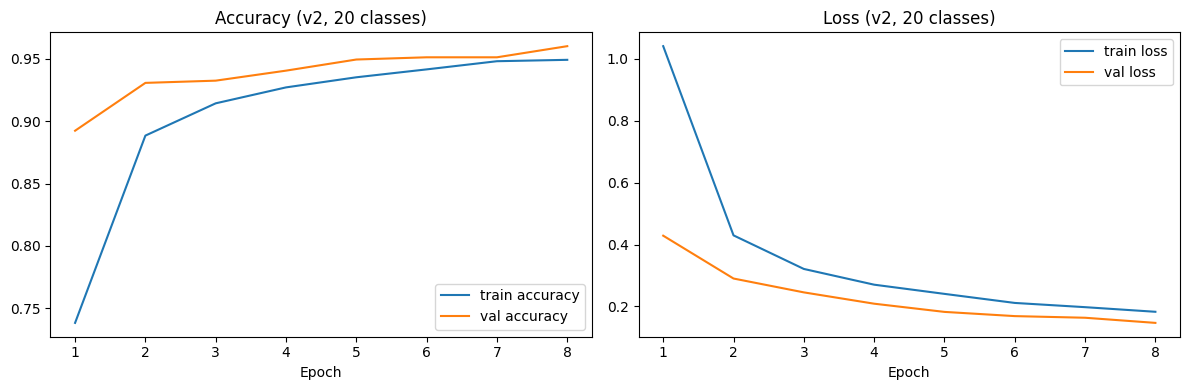

In [9]:
# [MODEL] 학습/검증 정확도와 손실을 그래프로 시각화하여 학습 추이를 확인한다
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, acc, label='train accuracy')
axes[0].plot(epochs_range, val_acc, label='val accuracy')
axes[0].set_title('Accuracy (v2, 20 classes)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, loss, label='train loss')
axes[1].plot(epochs_range, val_loss, label='val loss')
axes[1].set_title('Loss (v2, 20 classes)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. test set 평가: 전체 정확도 + 클래스별 정확도 + 혼동행렬

20종 전체에 대한 test 정확도와 클래스별 정확도를 계산하고,
특히 외형이 비슷한 대파(green_onion)-양파(onion) 등 클래스 쌍의 오분류를 별도로 확인한다.

In [10]:
# [MODEL] test 데이터셋으로 20종 전체 정확도를 평가한다
test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test accuracy (20 classes): {test_accuracy:.4f}')

36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 740ms/step - accuracy: 0.9666 - loss: 0.1291
Test accuracy (20 classes): 0.9666


=== 클래스별 정확도 (v2, 20종) ===
potato: 100.00%
carrot: 100.00%
cabbage: 100.00%
tomato: 98.57%
eggplant: 96.00%
paprika: 95.00%
pork: 98.39%
chicken: 98.44%
onion: 86.67%
egg: 92.73%
garlic: 94.52%
tofu: 96.00%
cheese: 90.62%
somyeon: 96.97%
enoki_mushroom: 100.00%
green_onion: 96.77%
vienna_sausage: 98.39%
canned_tuna: 100.00%
cucumber: 98.41%
kimchi: 96.77%


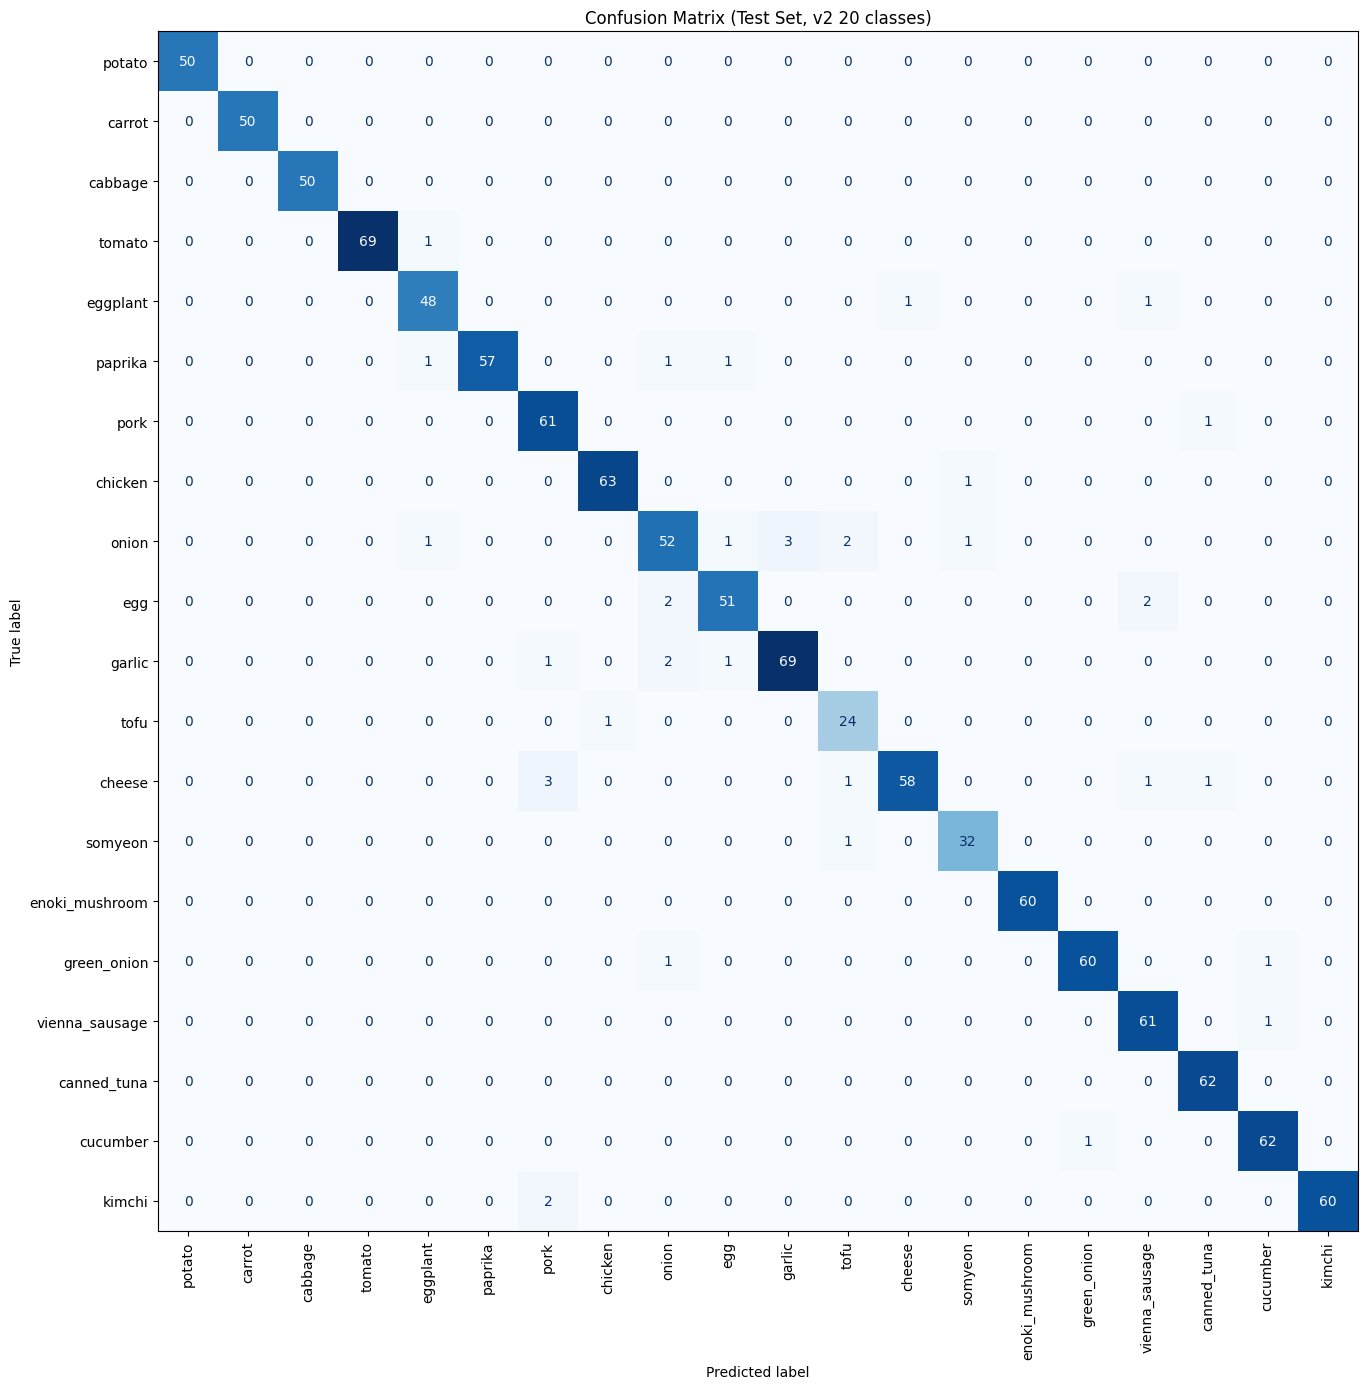

                precision    recall  f1-score   support

        potato       1.00      1.00      1.00        50
        carrot       1.00      1.00      1.00        50
       cabbage       1.00      1.00      1.00        50
        tomato       1.00      0.99      0.99        70
      eggplant       0.94      0.96      0.95        50
       paprika       1.00      0.95      0.97        60
          pork       0.91      0.98      0.95        62
       chicken       0.98      0.98      0.98        64
         onion       0.90      0.87      0.88        60
           egg       0.94      0.93      0.94        55
        garlic       0.96      0.95      0.95        73
          tofu       0.86      0.96      0.91        25
        cheese       0.98      0.91      0.94        64
       somyeon       0.94      0.97      0.96        33
enoki_mushroom       1.00      1.00      1.00        60
   green_onion       0.98      0.97      0.98        62
vienna_sausage       0.94      0.98      0.96  

In [11]:
# [MODEL] 실제 라벨과 예측 라벨을 모아 혼동행렬과 클래스별 정확도를 계산한다
test_generator.reset()
steps = math.ceil(test_generator.samples / BATCH_SIZE)
pred_probs = model.predict(test_generator, steps=steps, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)[:test_generator.samples]
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))

# 클래스별 정확도 (혼동행렬 대각선 / 행 합)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print('=== 클래스별 정확도 (v2, 20종) ===')
for name, acc_value in zip(CLASS_NAMES, per_class_acc):
    print(f'{name}: {acc_value:.2%}')

fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Test Set, v2 20 classes)')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, labels=range(len(CLASS_NAMES))))

In [12]:
# [MODEL] 외형이 비슷해 혼동되기 쉬운 대파(green_onion)-양파(onion) 쌍을 별도로 점검한다
onion_idx = CLASS_NAMES.index('onion')
green_onion_idx = CLASS_NAMES.index('green_onion')

onion_to_green_onion = cm[onion_idx, green_onion_idx]
green_onion_to_onion = cm[green_onion_idx, onion_idx]

print(f'양파를 대파로 오분류한 건수: {onion_to_green_onion} / 양파 test 총 {cm[onion_idx].sum()}건')
print(f'대파를 양파로 오분류한 건수: {green_onion_to_onion} / 대파 test 총 {cm[green_onion_idx].sum()}건')

# 오분류 비율이 눈에 띄게 높으면(10% 초과) 데이터 보강이 필요하다는 경고를 남긴다
for from_idx, to_idx, from_name, to_name in [
    (onion_idx, green_onion_idx, '양파', '대파'),
    (green_onion_idx, onion_idx, '대파', '양파'),
]:
    row_total = cm[from_idx].sum()
    ratio = cm[from_idx, to_idx] / row_total if row_total else 0.0
    if ratio > 0.1:
        print(f'경고: {from_name} -> {to_name} 오분류율 {ratio:.1%}로 높음. 데이터 보강 검토 필요')

양파를 대파로 오분류한 건수: 0 / 양파 test 총 60건
대파를 양파로 오분류한 건수: 1 / 대파 test 총 62건


## 7. 기존 6종 정확도 재학습 전/후 비교

기존 `ingredient_model.keras`가 동일한 기존 6종 test 이미지에서 보이던 정확도(재학습 전)와,
새 v2 모델이 20종 중 기존 6종에 대해 보이는 정확도(재학습 후)를 비교한다.
클래스별 하락폭이 5%p를 넘으면 데이터 보강 또는 학습 전략(추가 fine-tuning, 학습률 조정 등) 재검토가 필요하다.

In [13]:
# [MODEL] 재학습 전: 기존 모델을 기존 6종 test 서브셋에 대해서만 평가한다
old_test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=OLD_CLASS_NAMES, shuffle=False)

old_steps = math.ceil(old_test_generator.samples / BATCH_SIZE)

if warm_start_applied:
    old_pred_probs = old_model.predict(old_test_generator, steps=old_steps, verbose=0)
    old_y_pred = np.argmax(old_pred_probs, axis=1)[:old_test_generator.samples]
    old_y_true = old_test_generator.classes

    old_cm = confusion_matrix(old_y_true, old_y_pred, labels=range(len(OLD_CLASS_NAMES)))
    old_class_acc = old_cm.diagonal() / old_cm.sum(axis=1)
else:
    print('기존 모델을 불러오지 못해 재학습 전 정확도를 계산할 수 없다 (warm start 미적용)')
    old_class_acc = np.full(len(OLD_CLASS_NAMES), np.nan)

# 재학습 후: 앞서 계산한 20종 혼동행렬에서 기존 6종에 해당하는 클래스별 정확도를 그대로 사용한다
new_class_acc = per_class_acc[:len(OLD_CLASS_NAMES)]

print('=== 기존 6종 정확도 비교 (재학습 전 -> 후) ===')
DROP_THRESHOLD = 0.05  # 5%p
needs_review = []
for name, before, after in zip(OLD_CLASS_NAMES, old_class_acc, new_class_acc):
    diff = after - before
    flag = ''
    if not np.isnan(before) and diff < -DROP_THRESHOLD:
        flag = '  <- 하락폭 5%p 초과, 검토 필요'
        needs_review.append(name)
    print(f'{name}: {before:.2%} -> {after:.2%} (diff {diff:+.2%}){flag}')

if needs_review:
    print()
    print('경고: 다음 기존 클래스는 재학습 후 정확도가 5%p 넘게 하락했다 ->', needs_review)
    print('데이터 보강(해당 클래스 이미지 추가 수집) 또는 학습 전략 재검토(백본 일부 unfreeze, 학습률 조정, epoch 증가)가 필요하다')
else:
    print()
    print('기존 6종 모두 하락폭이 5%p 이내로 유지되었다')

Found 330 images belonging to 6 classes.
=== 기존 6종 정확도 비교 (재학습 전 -> 후) ===
potato: 100.00% -> 100.00% (diff +0.00%)
carrot: 100.00% -> 100.00% (diff +0.00%)
cabbage: 100.00% -> 100.00% (diff +0.00%)
tomato: 90.00% -> 98.57% (diff +8.57%)
eggplant: 100.00% -> 96.00% (diff -4.00%)
paprika: 100.00% -> 95.00% (diff -5.00%)  <- 하락폭 5%p 초과, 검토 필요

경고: 다음 기존 클래스는 재학습 후 정확도가 5%p 넘게 하락했다 -> ['paprika']
데이터 보강(해당 클래스 이미지 추가 수집) 또는 학습 전략 재검토(백본 일부 unfreeze, 학습률 조정, epoch 증가)가 필요하다


## 8. 모델 및 클래스명(v2) 저장

v2 모델과 20종 클래스명 순서를 `model/artifacts/ingredient_model_v2.keras`,
`model/artifacts/class_names_v2.json`으로 저장한다.

In [17]:
# [MODEL] v2 모델과 클래스명 순서를 model/artifacts 하위에 저장한다
MODEL_V2_PATH = os.path.join(ARTIFACT_DIR, 'ingredient_model_v2.keras')
CLASS_NAMES_V2_PATH = os.path.join(ARTIFACT_DIR, 'class_names_v2.json')

model.save(MODEL_V2_PATH)

# 클래스명은 저장 시 예측 결과의 인덱스와 항상 같은 순서를 유지해야 하므로 CLASS_NAMES를 그대로 기록한다
with open(CLASS_NAMES_V2_PATH, 'w', encoding='utf-8') as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

print(f'v2 모델 저장 완료: {MODEL_V2_PATH}')
print(f'v2 클래스명 저장 완료: {CLASS_NAMES_V2_PATH}')

v2 모델 저장 완료: /content/drive/MyDrive/ingredient-project/model/artifacts/ingredient_model_v2.keras
v2 클래스명 저장 완료: /content/drive/MyDrive/ingredient-project/model/artifacts/class_names_v2.json


## 9. 예측 함수 데모 (predict_image) — 20종 각 1장씩 검증

`predict_image(path)`는 예측 클래스명(name), 확신도(confidence), top3 결과를 딕셔너리로 반환한다.
20개 클래스 각각에서 test 이미지 1장씩을 뽑아 예측을 검증한다.

In [14]:
def predict_image(path, model=model, class_names=CLASS_NAMES, img_size=IMG_SIZE):
    img = tf.keras.utils.load_img(path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)   # /255.0 제거
    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    top3_idx = np.argsort(predictions)[::-1][:3]
    top3 = [
        {'name': class_names[i], 'confidence': float(predictions[i])}
        for i in top3_idx
    ]

    best_idx = int(top3_idx[0])
    return {
        'name': class_names[best_idx],
        'confidence': float(predictions[best_idx]),
        'top3': top3,
    }

In [16]:
# [MODEL] 20개 클래스 각각에서 test 이미지 1장씩을 뽑아 predict_image로 검증한다
correct_count = 0
total_count = 0

for cls in CLASS_NAMES:
    cls_dir = os.path.join(test_dir, cls)
    files = os.listdir(cls_dir)
    if not files:
        print(f'{cls}: test 이미지 없음, 건너뜀')
        continue

    sample_path = os.path.join(cls_dir, files[0])
    result = predict_image(sample_path)

    total_count += 1
    is_correct = result['name'] == cls
    correct_count += int(is_correct)

    mark = 'O' if is_correct else 'X'
    print(f"[{mark}] 정답={cls} -> 예측={result['name']} ({result['confidence']:.2%}) top3={result['top3']}")

print()
print(f'20종 샘플 검증 결과: {correct_count}/{total_count} 정답')

[O] 정답=potato -> 예측=potato (99.10%) top3=[{'name': 'potato', 'confidence': 0.9910373687744141}, {'name': 'onion', 'confidence': 0.00747125968337059}, {'name': 'vienna_sausage', 'confidence': 0.000457563204690814}]
[O] 정답=carrot -> 예측=carrot (99.96%) top3=[{'name': 'carrot', 'confidence': 0.9996240139007568}, {'name': 'vienna_sausage', 'confidence': 0.0003634149907156825}, {'name': 'chicken', 'confidence': 1.2155354852438904e-05}]
[O] 정답=cabbage -> 예측=cabbage (99.90%) top3=[{'name': 'cabbage', 'confidence': 0.9990092515945435}, {'name': 'somyeon', 'confidence': 0.00022149745200295}, {'name': 'chicken', 'confidence': 0.00013248409959487617}]
[O] 정답=tomato -> 예측=tomato (99.88%) top3=[{'name': 'tomato', 'confidence': 0.9988353848457336}, {'name': 'eggplant', 'confidence': 0.0005222707986831665}, {'name': 'onion', 'confidence': 0.0002955057134386152}]
[O] 정답=eggplant -> 예측=eggplant (99.89%) top3=[{'name': 'eggplant', 'confidence': 0.9989286065101624}, {'name': 'paprika', 'confidence': 0.001